# Klasifikasi Sentimen Ulasan Wisata Pulau Merak
### Implementasi Step-by-Step Menggunakan Complement Naive Bayes dan TF-IDF

Notebook ini dirancang untuk menjelaskan seluruh alur data (data pipeline) pada proyek **Analisis Sentimen Wisata Pulau Merak (Merak Besar dan Merak Kecil)** secara terstruktur dan bertahap (step-by-step). 

Tujuan utama kita adalah mengklasifikasikan ulasan pengunjung ke dalam 3 Kategori Sentimen:
1.  **Positif** (Ulasan dengan kepuasan tinggi/apresiatif)
2.  **Netral** (Ulasan berupa saran atau tidak menunjukkan emosi kuat)
3.  **Negatif** (Ulasan berisi keluhan tentang fasilitas, kebersihan, atau pelayanan)

---

## Step 1: Import Library dan Setup Lingkungan

Tahap pertama adalah memuat seluruh pustaka (libraries) yang dibutuhkan untuk pengolahan data, visualisasi, preprocessing bahasa Indonesia (menggunakan Sastrawi), ekstraksi fitur (TF-IDF), dan pemodelan (Complement Naive Bayes).

In [5]:
import os
import re
import string
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & NLP Bahasa Indonesia
import nltk
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Machine Learning Scikit-Learn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import ComplementNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Unduh data tokenisasi NLTK
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt', quiet=True)

try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab', quiet=True)

print("Setup lingkungan sukses! Semua library berhasil dimuat.")

Setup lingkungan sukses! Semua library berhasil dimuat.


## Step 2: Memuat dan Eksplorasi Dataset

Dataset yang digunakan adalah data ulasan pengunjung Pulau Merak yang disimpan dalam file CSV `dataset/dataset_master_merak_lengkap.csv`. Kita akan memuat data ini menggunakan Pandas, memeriksa kolom yang tersedia, dan memetakan rating ulasan (bintang) ke label sentimen yang sesuai.

In [6]:
# Tentukan path ke dataset
csv_path = os.path.join('dataset', 'dataset_master_merak_lengkap.csv')

# Memuat dataset
if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    print(f"Berhasil memuat dataset. Ukuran data: {df.shape[0]} baris dan {df.shape[1]} kolom.\n")
    # Tampilkan 5 baris pertama
    display(df.head())
else:
    print(f"File tidak ditemukan di {csv_path}. Pastikan Anda menjalankan notebook di root direktori proyek.")

Berhasil memuat dataset. Ukuran data: 833 baris dan 6 kolom.



,Tanggal,Nama User,Rating,Teks Ulasan,Label Sentimen,Lokasi
0,3 bulan lalu,Retno Septiana,5 bintang,Tiket penyebrangan 20k pp sangat terjangkau da...,NaN,Pulau Merak Besar
1,5 bulan lalu,Tiara Pertiwi,5 bintang,Tempatnya cantik banget!!! warga yang ngelola ...,NaN,Pulau Merak Besar
2,2 bulan lalu,Hikari San,4 bintang,"Kesana pas tgl 16 Feb, tiket perahu 25K/orang....",NaN,Pulau Merak Besar
3,7 bulan lalu,Lidya Zulfina Rahmawati,5 bintang,Kesini pas siang karena sempat ke delay pagi h...,NaN,Pulau Merak Besar
4,6 bulan lalu,Indah Sitompul,5 bintang,Bener-bener jadi pilihan tepat buat liburan pr...,NaN,Pulau Merak Besar


### Pemetaan Rating ke Kategori Sentimen

Pada aplikasi kita, rating ulasan (seperti "5 bintang", "3 bintang", atau berupa angka) dipetakan ke dalam kategori sentimen berdasarkan aturan berikut:
-   Rating 4 dan 5: Sentimen Positif
-   Rating 3: Sentimen Netral
-   Rating 1 dan 2: Sentimen Negatif

Kita juga akan mem-parsing kolom Tanggal untuk mengambil data tahun dan bulan untuk kebutuhan analisis tren.

Distribusi Kelas Sentimen Terpetakan:
Label Sentimen
positif    755
negatif     41
netral      37
Name: count, dtype: int64


C:\Users\HP\AppData\Local\Temp\ipykernel_32136\2659832339.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Rating_Angka', data=df, palette='viridis')
C:\Users\HP\AppData\Local\Temp\ipykernel_32136\2659832339.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Label Sentimen', data=df, palette={'positif': '#2ec4b6', 'netral': '#ffbf00', 'negatif': '#e63946'})


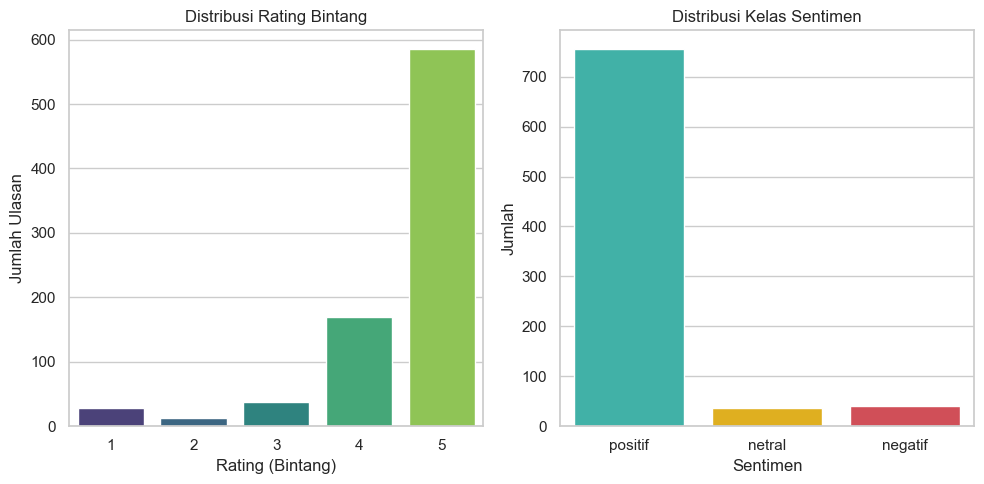

In [7]:
def map_rating_to_sentiment(rating_input):
    """Memetakan string rating (misal: '5 bintang') ke sentimen."""
    if isinstance(rating_input, (int, float)):
        val = int(rating_input)
    elif isinstance(rating_input, str):
        try:
            val = int(rating_input.split()[0])
        except (ValueError, IndexError):
            val = 3
    else:
        val = 3
    
    if val >= 4:
        return 'positif', val
    elif val == 3:
        return 'netral', val
    else:
        return 'negatif', val

# Mengaplikasikan fungsi pemetaan
mapped_results = df['Rating'].apply(map_rating_to_sentiment)
df['Label Sentimen'] = [res[0] for res in mapped_results]
df['Rating_Angka'] = [res[1] for res in mapped_results]

# Bersihkan baris yang ulasannya kosong
df = df.dropna(subset=['Teks Ulasan'])

print("Distribusi Kelas Sentimen Terpetakan:")
print(df['Label Sentimen'].value_counts())

# Visualisasi Distribusi Kelas menggunakan Matplotlib & Seaborn
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

plt.subplot(1, 2, 1)
sns.countplot(x='Rating_Angka', data=df, palette='viridis')
plt.title('Distribusi Rating Bintang')
plt.xlabel('Rating (Bintang)')
plt.ylabel('Jumlah Ulasan')

plt.subplot(1, 2, 2)
sns.countplot(x='Label Sentimen', data=df, palette={'positif': '#2ec4b6', 'netral': '#ffbf00', 'negatif': '#e63946'})
plt.title('Distribusi Kelas Sentimen')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah')

plt.tight_layout()
plt.show()

## Step 3: Text Preprocessing Pipeline (Bahasa Indonesia)

Sebelum data teks diumpankan ke model Machine Learning, teks tersebut harus dibersihkan terlebih dahulu. Proses preprocessing ini terdiri dari 6 tahap:
1.  **Case Folding**: Mengubah semua teks menjadi huruf kecil (lowercase).
2.  **Text Cleaning**: Menghapus URL, mention (@user), hashtag (#tag), tag HTML, angka, tanda baca, dan spasi berlebih.
3.  **Word Normalization**: Mengubah kata singkatan atau tidak baku (bahasa gaul) menjadi kata baku bahasa Indonesia (contoh: "yg" -> "yang", "gak" -> "tidak") menggunakan kamus normalisasi.
4.  **Tokenization**: Memecah kalimat utuh menjadi list kata-kata (tokens).
5.  **Stopwords Removal**: Menghapus kata-kata umum yang tidak membawa makna sentimen (contoh: "yang", "di", "dari"). Kata negasi seperti **"tidak", "kurang", "bukan", "jangan", "belum"** secara sengaja **tidak dihapus** agar tidak merusak makna sentimen.
6.  **Stemming**: Mengubah kata berimbuhan menjadi kata dasar menggunakan **Sastrawi Stemmer** (contoh: "pelayanan" -> "layan", "mengelola" -> "kelola").

In [8]:
# Kamus Normalisasi Kata Gaul/Singkatan Bahasa Indonesia
NORMALIZATION_DICT = {
    'gak': 'tidak', 'ga': 'tidak', 'gk': 'tidak', 'tdk': 'tidak',
    'nggak': 'tidak', 'ngga': 'tidak', 'enggak': 'tidak',
    'yg': 'yang', 'dgn': 'dengan', 'utk': 'untuk', 'kpd': 'kepada',
    'dr': 'dari', 'pd': 'pada', 'dlm': 'dalam', 'krn': 'karena',
    'trs': 'terus', 'tp': 'tapi', 'tpi': 'tapi', 'sdh': 'sudah',
    'udh': 'sudah', 'udah': 'sudah', 'blm': 'belum', 'blum': 'belum',
    'bgt': 'sangat', 'bngt': 'sangat', 'bngtt': 'sangat',
    'sm': 'sama', 'org': 'orang', 'bkn': 'bukan',
    'klo': 'kalau', 'kl': 'kalau', 'klu': 'kalau',
    'jg': 'juga', 'jgn': 'jangan', 'lg': 'lagi',
    'emg': 'memang', 'emang': 'memang',
    'bs': 'bisa', 'aj': 'saja', 'aja': 'saja',
    'bgs': 'bagus', 'bgus': 'bagus',
    'jlk': 'jelek', 'jlek': 'jelek',
    'krg': 'kurang', 'brg': 'barang',
    'mantap': 'bagus', 'mantab': 'bagus', 'mantul': 'bagus',
    'oke': 'baik', 'ok': 'baik',
    'thx': 'terima kasih', 'tq': 'terima kasih', 'makasih': 'terima kasih',
    'mksh': 'terima kasih', 'makasi': 'terima kasih',
}

# Inisialisasi Sastrawi Stemmer dan StopWord
stemmer_factory = StemmerFactory()
stemmer = stemmer_factory.create_stemmer()

stopword_factory = StopWordRemoverFactory()
# Lindungi kata-kata negasi agar sentimen tetap terjaga
NEGATION_WORDS = {'tidak', 'kurang', 'bukan', 'jangan', 'tak', 'tiada', 'belum'}
stopwords_id = set(stopword_factory.get_stop_words()) - NEGATION_WORDS

# Stopwords tambahan khusus sentimen
CUSTOM_STOPWORDS = {
    'yg', 'dgn', 'nya', 'utk', 'klo', 'gak', 'ga', 'gk',
    'tp', 'tpi', 'udh', 'udah', 'sdh', 'blm', 'blum',
    'bgt', 'banget', 'aja', 'sih', 'deh', 'dong', 'nih',
    'lho', 'lah', 'kan', 'ya', 'yaa', 'ko', 'kok'
}

def case_folding(text):
    return text.lower()

def clean_text(text):
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # URL
    text = re.sub(r'@\w+', '', text) # Mentions
    text = re.sub(r'#\w+', '', text) # Hashtags
    text = re.sub(r'<.*?>', '', text) # HTML
    text = re.sub(r'\d+', '', text) # Angka
    text = text.translate(str.maketrans('', '', string.punctuation)) # Punctuation
    text = re.sub(r'\s+', ' ', text).strip() # Extra Spaces
    return text

def normalize_text(text):
    words = text.split()
    normalized = [NORMALIZATION_DICT.get(word, word) for word in words]
    return ' '.join(normalized)

def tokenize(text):
    return nltk.word_tokenize(text)

def remove_stopwords(tokens):
    all_stopwords = stopwords_id | CUSTOM_STOPWORDS
    return [token for token in tokens if token not in all_stopwords and len(token) > 1]

def stem_tokens(tokens):
    return [stemmer.stem(token) for token in tokens]

def preprocess_text(text):
    text = case_folding(text)
    text = clean_text(text)
    text = normalize_text(text)
    tokens = tokenize(text)
    tokens = remove_stopwords(tokens)
    tokens = stem_tokens(tokens)
    return ' '.join(tokens)

print("Preprocessing pipeline berhasil didefinisikan!")

Preprocessing pipeline berhasil didefinisikan!


### Simulasi Preprocessing Step-by-Step

Mari kita uji fungsi pembersihan teks kita dengan menggunakan kalimat ulasan tiruan yang memiliki kata gaul, tanda baca, angka, hashtag, dan kata negasi. Ini membantu kita memvisualisasikan bagaimana sebuah kalimat bertransformasi pada setiap step secara transparan.

In [9]:
sample_review = "Wah parah bgt!!! Kapal penyeberangannya telat 2 jam, toiletnya kotor & bau bgt di pulau merak besar. Tapi untung pantainya tdk kotor bgt dan airnya bening. @pengelola #kecewa #liburan"

print("Kalimat Asli:")
print(sample_review)
print("-" * 80)

# Step 1: Case Folding
step1 = case_folding(sample_review)
print(f"1. Case Folding:   {step1}")

# Step 2: Clean Text
step2 = clean_text(step1)
print(f"2. Cleaning:       {step2}")

# Step 3: Normalization
step3 = normalize_text(step2)
print(f"3. Normalisasi:    {step3}")

# Step 4: Tokenize
step4 = tokenize(step3)
print(f"4. Tokenisasi:     {step4}")

# Step 5: Stopwords Removal
step5 = remove_stopwords(step4)
print(f"5. Hapus Stopword: {step5}")

# Step 6: Stemming
step6 = stem_tokens(step5)
print(f"6. Stemming Sastrawi: {step6}")

# Hasil Akhir
final_result = ' '.join(step6)
print("-" * 80)
print(f"Hasil Akhir Preprocessing: '{final_result}'")

Kalimat Asli:
Wah parah bgt!!! Kapal penyeberangannya telat 2 jam, toiletnya kotor & bau bgt di pulau merak besar. Tapi untung pantainya tdk kotor bgt dan airnya bening. @pengelola #kecewa #liburan
--------------------------------------------------------------------------------
1. Case Folding:   wah parah bgt!!! kapal penyeberangannya telat 2 jam, toiletnya kotor & bau bgt di pulau merak besar. tapi untung pantainya tdk kotor bgt dan airnya bening. @pengelola #kecewa #liburan
2. Cleaning:       wah parah bgt kapal penyeberangannya telat jam toiletnya kotor bau bgt di pulau merak besar tapi untung pantainya tdk kotor bgt dan airnya bening
3. Normalisasi:    wah parah sangat kapal penyeberangannya telat jam toiletnya kotor bau sangat di pulau merak besar tapi untung pantainya tidak kotor sangat dan airnya bening
4. Tokenisasi:     ['wah', 'parah', 'sangat', 'kapal', 'penyeberangannya', 'telat', 'jam', 'toiletnya', 'kotor', 'bau', 'sangat', 'di', 'pulau', 'merak', 'besar', 'tapi', 'untun

### Jalankan Preprocessing ke Seluruh Dataset

Catatan: Karena proses stemming menggunakan pustaka Sastrawi memerlukan waktu beberapa saat untuk ribuan ulasan, kita akan menampilkan status kemajuan sederhana.

In [10]:
print("Memulai pembersihan seluruh dataset ulasan (mungkin memakan waktu 1-2 menit)...")

# Mengaplikasikan preprocessing ke seluruh baris ulasan
df['Clean_Teks'] = df['Teks Ulasan'].apply(preprocess_text)

print("Pembersihan data ulasan selesai!")
# Tampilkan perbandingan ulasan asli dan ulasan bersih
display(df[['Teks Ulasan', 'Clean_Teks', 'Label Sentimen']].head(10))

Memulai pembersihan seluruh dataset ulasan (mungkin memakan waktu 1-2 menit)...
Pembersihan data ulasan selesai!


,Teks Ulasan,Clean_Teks,Label Sentimen
0,Tiket penyebrangan 20k pp sangat terjangkau da...,tiket penyebrangan pp sangat jangkau pantai be...,positif
1,Tempatnya cantik banget!!! warga yang ngelola ...,tempat cantik warga ngelola ramah ramah helpfu...,positif
2,"Kesana pas tgl 16 Feb, tiket perahu 25K/orang....",kesana pas tgl feb tiket perahu korang pantai ...,positif
3,Kesini pas siang karena sempat ke delay pagi h...,kesini pas siang sempat delay pagi hari ombak ...,positif
4,Bener-bener jadi pilihan tepat buat liburan pr...,benerbener jadi pilih tepat buat libur privat ...,positif
5,Merak besar destinasi wisata yang 'dekat' deng...,merak besar destinasi wisata dekat jakarta jam...,positif
6,Datang saat cuaca lagi cerah dan airnya bening...,datang cuaca cerah air bening wah masyaallah k...,positif
7,Anak² muda setempatnya keren mengelola tempat ...,anak muda tempat keren kelola tempat jadi obje...,positif
8,pantainya cakep banget!!!!! pelayanannya bagus...,pantai cakep layan bagus sedikit banyak sampah...,positif
9,Mantap ..view bagus..air nya bening bgt. Samp...,bagus view bagusair bening sangat lihat karang...,positif


## Step 4: Split Dataset dan Mengatasi Ketidakseimbangan Kelas (Oversampling)

Dataset ulasan wisata umumnya memiliki ketidakseimbangan kelas (class imbalance) di mana jumlah ulasan Positif jauh lebih melimpah daripada Netral dan Negatif.

Jika model langsung dilatih dengan kondisi timpang seperti ini, model akan bias ke kelas mayoritas (Positif) dan kesulitan mengenali ulasan Negatif atau Netral.

Untuk mengatasinya:
1.  Kita bagi data menjadi 80% untuk Training dan 20% untuk Testing dengan teknik stratify agar rasio kelas tetap seimbang antara train & test set.
2.  Kita terapkan teknik Strong Oversampling pada data Training. Kelas minoritas (Netral dan Negatif) akan digandakan (direplikasi) hingga jumlahnya tepat sama dengan jumlah kelas mayoritas (Positif).

In [11]:
# Ekstraksi data ulasan bersih dan label
texts = df['Clean_Teks'].tolist()
labels = df['Label Sentimen'].tolist()

# Pembagian data train dan test (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"Ukuran Data Train Sebelum Oversampling: {len(X_train)} sampel")
print("Distribusi Kelas pada Data Train Asli:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"   - Sentimen {u}: {c} data")

print("-" * 50)
print("Menerapkan Strong Oversampling pada Data Training...")

X_train = np.array(X_train)
y_train = np.array(y_train)

unique_labels, counts = np.unique(y_train, return_counts=True)
max_count = max(counts)  # Ambil jumlah kelas mayoritas

X_resampled = []
y_resampled = []

for label, count in zip(unique_labels, counts):
    indices = np.where(y_train == label)[0]
    label_X = X_train[indices]
    
    # Gandakan data minoritas agar sama dengan mayoritas
    repeat_factor = max_count // len(label_X)
    remainder = max_count % len(label_X)
    
    resampled_X = np.concatenate([label_X] * repeat_factor + [label_X[:remainder]])
    resampled_y = [label] * max_count
    
    X_resampled.extend(resampled_X)
    y_resampled.extend(resampled_y)

X_train_balanced = X_resampled
y_train_balanced = y_resampled

print(f"Ukuran Data Train Sesudah Oversampling: {len(X_train_balanced)} sampel")
print("Distribusi Kelas pada Data Train Seimbang:")
unique_bal, counts_bal = np.unique(y_train_balanced, return_counts=True)
for u, c in zip(unique_bal, counts_bal):
    print(f"   - Sentimen {u}: {c} data")

Ukuran Data Train Sebelum Oversampling: 666 sampel
Distribusi Kelas pada Data Train Asli:
   - Sentimen negatif: 33 data
   - Sentimen netral: 29 data
   - Sentimen positif: 604 data
--------------------------------------------------
Menerapkan Strong Oversampling pada Data Training...
Ukuran Data Train Sesudah Oversampling: 1812 sampel
Distribusi Kelas pada Data Train Seimbang:
   - Sentimen negatif: 604 data
   - Sentimen netral: 604 data
   - Sentimen positif: 604 data


## Step 5: Ekstraksi Fitur (TF-IDF Vectorization)

Komputer tidak memahami teks mentah secara langsung. Oleh karena itu, kita perlu mengubah teks bersih menjadi representasi numerik menggunakan metode TF-IDF (Term Frequency - Inverse Document Frequency).

Di sini kita menggunakan parameter:
-   `max_features=5000`: Mengambil 5000 kata/kombinasi kata yang paling penting.
-   `ngram_range=(1, 2)`: Menggunakan unigram (kata tunggal) dan bigram (pasangan kata bersebelahan, contoh: "sangat_bagus", "tidak_bersih"). Ini sangat berguna untuk menangkap konteks negasi secara tepat.

In [12]:
# Inisialisasi TF-IDF Vectorizer
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

# Fitting & Transformasikan pada data train
X_train_tfidf = vectorizer.fit_transform(X_train_balanced)

# Transformasikan pada data test (hanya transform, dilarang fitting agar tidak terjadi data leakage)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Dimensi Matriks TF-IDF Data Train: {X_train_tfidf.shape}")
print(f"Dimensi Matriks TF-IDF Data Test:  {X_test_tfidf.shape}")
print(f"Jumlah Fitur Kosakata yang Diekstrak: {len(vectorizer.get_feature_names_out())}")

Dimensi Matriks TF-IDF Data Train: (1812, 5000)
Dimensi Matriks TF-IDF Data Test:  (167, 5000)
Jumlah Fitur Kosakata yang Diekstrak: 5000


## Step 6: Pelatihan Model (Complement Naive Bayes)

Kita menggunakan algoritma Complement Naive Bayes (CNB). 

**Kenapa Complement Naive Bayes?**
CNB adalah variasi dari Multinomial Naive Bayes yang dirancang khusus untuk menangani bias klasifikasi akibat ketidakseimbangan dataset teks. Meskipun kita sudah menerapkan oversampling, kombinasi oversampling dengan CNB terbukti memberikan hasil akurasi dan stabilitas recall tertinggi untuk kelas-kelas minoritas pada data ulasan wisata.

In [13]:
# Inisialisasi Model Complement Naive Bayes dengan smoothing alpha=0.1
model_cnb = ComplementNB(alpha=0.1)

# Pelatihan Model
print("Melatih model Complement Naive Bayes pada data training...")
model_cnb.fit(X_train_tfidf, y_train_balanced)
print("Pelatihan model selesai!")

Melatih model Complement Naive Bayes pada data training...
Pelatihan model selesai!


## Step 7: Evaluasi Model

Kita akan menguji kinerja model yang telah dilatih menggunakan data pengujian (X_test, y_test). Kita akan menghasilkan:
1.  Akurasi Keseluruhan
2.  Classification Report: Precision, Recall, dan F1-Score untuk masing-masing kelas (positif, netral, negatif).
3.  Confusion Matrix: Visualisasi seberapa banyak ulasan diprediksi dengan benar dan di mana kesalahan klasifikasi paling sering terjadi.

Akurasi Model pada Data Uji: 79.64%

Classification Report:
              precision    recall  f1-score   support

     negatif       0.14      0.25      0.18         8
      netral       0.09      0.12      0.11         8
     positif       0.92      0.86      0.89       151

    accuracy                           0.80       167
   macro avg       0.38      0.41      0.39       167
weighted avg       0.84      0.80      0.82       167



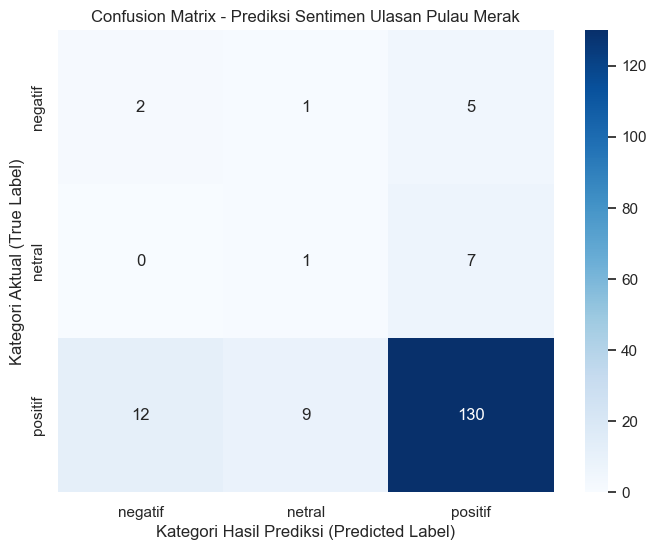

In [14]:
# Prediksi sentimen pada data test
y_pred = model_cnb.predict(X_test_tfidf)

# Hitung akurasi
accuracy = accuracy_score(y_test, y_pred)
print(f"Akurasi Model pada Data Uji: {accuracy * 100:.2f}%\n")

# Tampilkan Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['negatif', 'netral', 'positif']))

# Hitung Confusion Matrix
labels_list = ['negatif', 'netral', 'positif']
cm = confusion_matrix(y_test, y_pred, labels=labels_list)

# Visualisasi Heatmap Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', 
    xticklabels=labels_list, yticklabels=labels_list
)
plt.title('Confusion Matrix - Prediksi Sentimen Ulasan Pulau Merak')
plt.ylabel('Kategori Aktual (True Label)')
plt.xlabel('Kategori Hasil Prediksi (Predicted Label)')
plt.show()

## Step 8: Playground Prediksi Teks Real-Time

Mari kita buat fungsi pembungkus (wrapper) untuk memproses input teks ulasan baru secara instan, melakukan preprocessing, memprediksi sentimen, dan menampilkan persentase keyakinan model (probabilitas kelas).

In [15]:
def prediksi_sentimen_ulasan(teks_baru):
    """
    Memproses ulasan baru, melakukan klasifikasi sentimen,
    dan menampilkan probabilitas masing-masing kelas.
    """
    print(f"Ulasan Masuk: \"{teks_baru}\"")
    
    # 1. Jalankan Preprocessing
    teks_bersih = preprocess_text(teks_baru)
    print(f"Teks Bersih:  \"{teks_bersih}\"")
    
    # 2. Vektorisasi TF-IDF
    teks_tfidf = vectorizer.transform([teks_bersih])
    
    # 3. Prediksi Kelas & Probabilitas
    prediksi = model_cnb.predict(teks_tfidf)[0]
    probabilitas = model_cnb.predict_proba(teks_tfidf)[0]
    
    # Mapping kelas
    classes = model_cnb.classes_
    prob_dict = {classes[i]: probabilitas[i] for i in range(len(classes))}
    
    # Penentuan warna untuk display terminal
    warna = {'positif': '\033[92m', 'netral': '\033[93m', 'negatif': '\033[91m'}
    reset_warna = '\033[0m'
    
    print(f"Hasil Klasifikasi: {warna.get(prediksi, '')}{prediksi.upper()}{reset_warna} (Confidence: {prob_dict[prediksi]*100:.2f}%)")
    print("Distribusi Keyakinan:")
    for k, v in prob_dict.items():
        print(f"   - Sentimen {k.capitalize()}: {v*100:.2f}%")
    print("=" * 60 + "\n")

# Uji coba ulasan baru secara langsung
prediksi_sentimen_ulasan("tempatnya indah banget!! airnya bening dan warganya ramah ramah. wajib ke sini lagi nanti pas liburan!")
prediksi_sentimen_ulasan("pelayanan petugas penyebrangan sangat lelet, toiletnya kotor sekali ga ada air mengalir... kecewa")
prediksi_sentimen_ulasan("pantainya lumayan sih, cuma naik perahu ke sini antre panjang banget pas akhir pekan.")

Ulasan Masuk: "tempatnya indah banget!! airnya bening dan warganya ramah ramah. wajib ke sini lagi nanti pas liburan!"
Teks Bersih:  "tempat indah air bening warga ramah ramah wajib sini pas libur"
Hasil Klasifikasi: POSITIF (Confidence: 98.81%)
Distribusi Keyakinan:
   - Sentimen Negatif: 0.67%
   - Sentimen Netral: 0.51%
   - Sentimen Positif: 98.81%

Ulasan Masuk: "pelayanan petugas penyebrangan sangat lelet, toiletnya kotor sekali ga ada air mengalir... kecewa"
Teks Bersih:  "layan tugas penyebrangan sangat lelet toilet kotor sekali tidak air alir kecewa"
Hasil Klasifikasi: NEGATIF (Confidence: 96.26%)
Distribusi Keyakinan:
   - Sentimen Negatif: 96.26%
   - Sentimen Netral: 1.33%
   - Sentimen Positif: 2.41%

Ulasan Masuk: "pantainya lumayan sih, cuma naik perahu ke sini antre panjang banget pas akhir pekan."
Teks Bersih:  "pantai lumayan cuma naik perahu sini antre panjang pas akhir pekan"
Hasil Klasifikasi: POSITIF (Confidence: 92.82%)
Distribusi Keyakinan:
   - Sentimen Negatif

## Step 9: Menyimpan Model untuk Integrasi Flask

Agar model Complement Naive Bayes dan Vectorizer TF-IDF yang telah kita latih di notebook ini bisa digunakan pada dashboard web Flask, kita harus menyimpannya ke dalam file serialisasi menggunakan pustaka `joblib`.

Aplikasi Flask akan memuat file-file ini saat pertama kali dijalankan sehingga tidak perlu melatih model dari awal setiap kali ada permintaan prediksi baru.

In [16]:
# Direktori penyimpanan model sesuai dengan Config Flask
model_dir = 'model'
os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(model_dir, 'naive_bayes_model.pkl')
vectorizer_path = os.path.join(model_dir, 'tfidf_vectorizer.pkl')
metrics_path = os.path.join(model_dir, 'metrics.pkl')

# Metrik yang ingin kita simpan untuk dashboard web
metrics_data = {
    'accuracy': round(accuracy * 100, 2),
    'report': classification_report(y_test, y_pred, output_dict=True, zero_division=0),
    'confusion_matrix': confusion_matrix(y_test, y_pred, labels=['negatif', 'netral', 'positif']).tolist(),
    'train_size': len(X_train_balanced),
    'test_size': len(X_test),
    'labels': ['negatif', 'netral', 'positif']
}

# Ekspor file menggunakan joblib
joblib.dump(model_cnb, model_path)
joblib.dump(vectorizer, vectorizer_path)
joblib.dump(metrics_data, metrics_path)

print("Berhasil menyimpan aset model!")
print(f"   1. Model:      {model_path}")
print(f"   2. Vectorizer: {vectorizer_path}")
print(f"   3. Metrics:    {metrics_path}")
print("\nModel sekarang siap diintegrasikan dengan aplikasi web Flask!")

Berhasil menyimpan aset model!
   1. Model:      model\naive_bayes_model.pkl
   2. Vectorizer: model\tfidf_vectorizer.pkl
   3. Metrics:    model\metrics.pkl

Model sekarang siap diintegrasikan dengan aplikasi web Flask!
